In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import math
import statistics as st
from collections import Counter

from uq_pet.config import LLM_SCORES_DIR, NER_TAGS
from uq_pet.dataset import split_dataset

N_FEW_SHOT, FEW_SHOT_SEED = 1, 13
CACHE = LLM_SCORES_DIR / "nhr_oss_pool_fs1s13_topk2.json"
ARM_PARAMS = {"random": {"seed": 13}}  # the control's `seed:` knob, from the same config
BUDGET_PCT = 10  # the budget where the gap to random is widest

_, pool, test = split_dataset(n_few_shot=N_FEW_SHOT, few_shot_seed=FEW_SHOT_SEED)

In [3]:
import pandas as pd

from uq_pet.config import RESULTS_DIR
from uq_pet.dataset import sentence_key, to_examples

RUN_DIR = RESULTS_DIR / "nhr_gpt_oss_topk"
selection = json.loads((RUN_DIR / "selection.json").read_text())

# Sentence length = number of PET tokens. Keyed the same way selection.json is, so a
# selected key looks its length up directly.
pool_examples = to_examples(pool)
length = {sentence_key(ex): len(ex["tokens"]) for ex in pool_examples}

In [4]:
def length_stats(name: str, budget: str | None, keys: list[str]) -> dict:
    lengths = [length[k] for k in keys]
    return {
        "budget_pct": budget,
        "arm": name,
        "n": len(lengths),
        "mean": st.fmean(lengths),
        "median": st.median(lengths),
        "sd": st.stdev(lengths),
        "min": min(lengths),
        "max": max(lengths),
    }


rows = [length_stats("POOL", None, list(length))]
rows += [
    length_stats(arm, budget, keys)
    for budget, arms in selection.items()
    for arm, keys in arms.items()
]
lengths_df = pd.DataFrame(rows)

# How far each arm's mean sits from the pool mean, in pool standard deviations —
# a 33-sentence draw is small, so raw differences are easy to over-read.
pool_mean, pool_sd = lengths_df.loc[0, "mean"], lengths_df.loc[0, "sd"]
lengths_df["vs_pool"] = lengths_df["mean"] - pool_mean
lengths_df["z_of_mean"] = lengths_df["vs_pool"] / (pool_sd / lengths_df["n"] ** 0.5)

lengths_df.round(2)

,budget_pct,arm,n,mean,median,sd,min,max,vs_pool,z_of_mean
0,NaN,POOL,332,17.92,17.0,8.00,6,51,0.00,0.00
1,10,random,33,20.18,19.0,7.57,7,36,2.27,1.63
2,10,avg_neg_logprob_filtered,33,23.76,24.0,8.79,10,51,5.84,4.19
3,10,vote_entropy,33,23.79,26.0,9.14,6,40,5.87,4.22
4,10,pairwise_f1_disagreement,33,22.24,22.0,8.58,6,40,4.33,3.11
5,10,entity_count_std,33,26.79,28.0,7.55,10,40,8.87,6.37
6,10,least_confident,33,24.48,25.0,8.57,10,51,6.57,4.72
7,10,length,33,33.06,33.0,4.24,29,51,15.14,10.87
8,10,confident:avg_neg_logprob_filtered,33,15.39,13.0,7.59,6,34,-2.52,-1.81
9,20,random,66,19.30,18.5,8.31,7,49,1.39,1.41


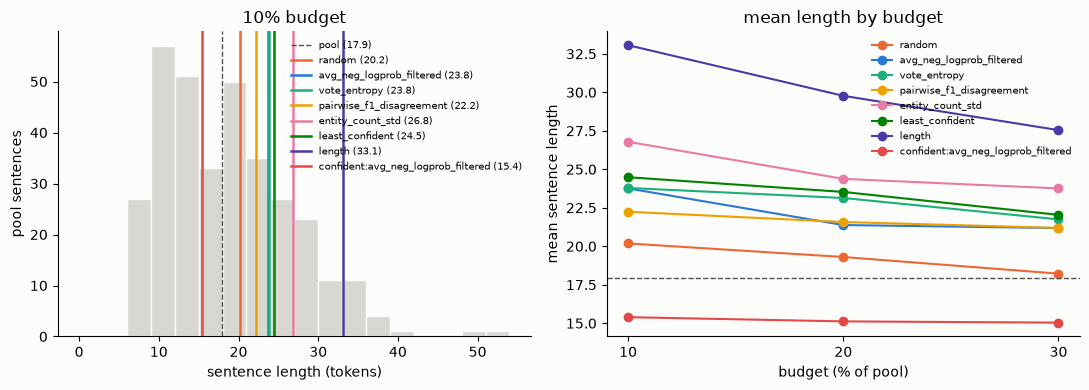

In [5]:
import matplotlib.pyplot as plt

from uq_pet.plotting import INK_SECONDARY, SURFACE, arm_colors

arms = list(selection[str(BUDGET_PCT)])
colors = arm_colors(arms)
budgets = list(selection)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor=SURFACE)

# Left: the pool's length distribution with each arm's mean at the smallest budget.
ax = axes[0]
ax.hist(list(length.values()), bins=range(0, 56, 3), color="#d8d7d2", edgecolor=SURFACE)
ax.axvline(pool_mean, color=INK_SECONDARY, ls="--", lw=1, label=f"pool ({pool_mean:.1f})")
for arm in arms:
    mean = st.fmean(length[k] for k in selection[str(BUDGET_PCT)][arm])
    ax.axvline(mean, color=colors[arm], lw=1.8, label=f"{arm} ({mean:.1f})")
ax.set(xlabel="sentence length (tokens)", ylabel="pool sentences", title=f"{BUDGET_PCT}% budget")
ax.legend(fontsize=7, frameon=False)

# Right: does the skew survive as the budget grows? By 30% each arm holds a third of
# the pool, so every line has to converge on the pool mean eventually.
ax = axes[1]
for arm in arms:
    means = [st.fmean(length[k] for k in selection[b][arm]) for b in budgets]
    ax.plot([int(b) for b in budgets], means, marker="o", color=colors[arm], label=arm)
ax.axhline(pool_mean, color=INK_SECONDARY, ls="--", lw=1)
ax.set(xlabel="budget (% of pool)", ylabel="mean sentence length", title="mean length by budget")
ax.set_xticks([int(b) for b in budgets])
ax.legend(fontsize=7, frameon=False, loc="upper right")

for ax in axes:
    ax.set_facecolor(SURFACE)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [16]:
from uq_pet.plotting import plot_learning_curve


results_path = RUN_DIR / "results.csv"
results = pd.read_csv(results_path)




In [17]:
results['arm'].unique()

<ArrowStringArray>
[                            'random',           'avg_neg_logprob_filtered',
                       'vote_entropy',           'pairwise_f1_disagreement',
                   'entity_count_std',                    'least_confident',
                             'length', 'confident:avg_neg_logprob_filtered']
Length: 8, dtype: str

In [18]:
results = results[results['arm'].isin(['random', 'least_confident', 'length', 'confident:avg_neg_logprob_filtered'])]

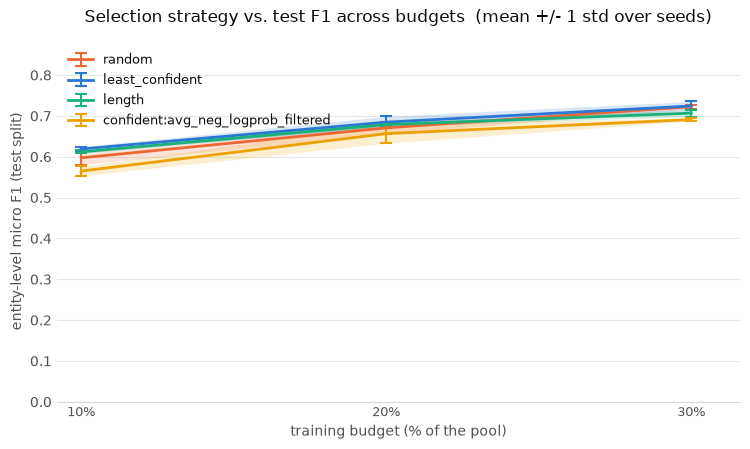

In [19]:
plot_learning_curve(results, RUN_DIR / "learning_curve.png", show=True)